# Why churning concepts spread, and the completed Exp11 closure test

This notebook is a demo of `method.py`, the entry point of the iteration-5 experiment. The experiment is cache-only and makes no LLM calls. It has three parts:

* **Part C: finishing the sealed Exp11 test.** The sealed Exp11 code is re-run with a patch that changes only file paths and with one BLAS thread per process, which fixes the Exp11 crash. It covers the within-concept closure hypotheses H-M1..H-M5 (PPML body models), the Sun-Abraham event study (H-M4), the sequence share test (H-S1) and the preregistered partner test (H-P1). The DEV verdict does not change: **NOT SUPPORTED**. On OLD_HELDOUT, `OPEN_home` comes out at -0.079 [-0.146, -0.013], which is the opposite sign to the prediction.
* **Part A (exploratory): why churning concepts spread.** Each concept's HOME partner churn (`NOVCHURN_home`) is split into 12 additive partner-class parts: METHOD or DOMAIN, new or old community, low or high degree, mixed or pure carrier, dropped or added. The signal comes from **new-community partners that arrive through mixed-field papers**.
* **Part B: trait stability.** This asks whether HOME openness is a stable trait. See `trait_stability.json` in the original artifact.

`method.py` runs about 13 stages in order: sealed-code setup, PPML, event study, partner builds, sealing, tests, scoring and trait ICC. Those stages take hours and need a multi-GB cache, so this demo does not re-run them. It runs the two parts that `method.py` computes itself:

1. **`exp11_completion()`** collects the Exp11 stage outputs into one summary, the same content as `results/exp11_completion.json`. The stage JSONs are included in `mini_demo_data.json`.
2. **`method_out()`** fits a 5-fold concept-CV ridge within each body (DEV, OLD_HELDOUT, COHORT_2010_14, COHORT_2015_17). The target is the reach outcome `O2r_m50`. It compares the **B5 baseline** with B5 + `NOVCHURN_home`, B5 + the 12 partner-class parts and B5 + `OPEN_home`, and runs a paired concept bootstrap of the Spearman gain.

The demo data has 100 concepts, 25 per body and stratified over field groups. The original run used 634 to 3,188 concepts per body. The code is the original `method.py`, split into cells. The only changes are that file paths now read the loaded `data` and that the tunable numbers come from the config cell.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, scikit-learn, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

## Imports

This is the original import block from `method.py`. The only difference is that `from common_iter5 import ...` is replaced by the next cell, which defines the same constants and helpers inline. matplotlib is added for the final plots.

In [2]:
from __future__ import annotations

import argparse
import json
import math
import os
import subprocess
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Helpers copied from `lib_iter5/common_iter5.py`

This cell defines the constants and helpers that `method.py` imports: `B5`, `SEED`, `jdump` and `setup_logger`. **B5** is the five-feature early-diffusion baseline: log volume, growth, off-home share, field entropy and reach. Every Part A contrast is measured against it. Outputs go to a local `demo_results/` folder, not to the original workspace.

In [3]:
WS = Path(".").resolve()
DATA, RES, LOGS = WS / "data", WS / "demo_results", WS / "logs"   # original: <workspace>/data, results, logs
for _d in (RES, LOGS):
    _d.mkdir(parents=True, exist_ok=True)

SEED = 20260929
B5 = ["logvol", "growth_c", "offhome_share", "entropy", "reach"]
HELD = ["PHYS", "LIFEENV", "SOC", "MATHDEC"]   # held-out field groups (OLD_HELDOUT body)


def setup_logger(name: str):
    from loguru import logger
    logger.remove()
    logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
    logger.add(LOGS / f"{name}.log", rotation="30 MB", level="DEBUG")
    return logger


def _clean(o):
    if isinstance(o, dict):
        return {str(k): _clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [_clean(v) for v in o]
    if isinstance(o, np.ndarray):
        return _clean(o.tolist())
    if isinstance(o, np.integer):
        return int(o)
    if isinstance(o, np.bool_):
        return bool(o)
    if isinstance(o, (np.floating, float)):
        return None if not math.isfinite(float(o)) else float(o)
    return o


def jdump(obj, path: Path) -> None:
    Path(path).write_text(json.dumps(_clean(obj), indent=1, default=str))

## Load the demo data

`mini_demo_data.json` has three parts:
* `partner_home_concepts` holds 100 concept rows from `data/partA_features_*.parquet`. Each row has the outcome `O2r_m50`, the B5 features, `NOVCHURN_home`, `OPEN_home`, the 12 partner-class parts and some metadata.
* `exp11_stage_results` holds the cached JSON outputs of the Exp11 stages: `seal_verification`, `fe_results_completed`, `event_study`, `sequence_tests`, `H_P1`, `unit_tests` and `deviations`.
* `full_run_cv_metrics` holds the CV metrics of the original full run, for comparison.

In [4]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_e4QYTG8fEPNh/round-5/experiment-15/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [5]:
data = load_data()
print({k: (len(v) if isinstance(v, (list, dict)) else v) for k, v in data.items() if k != "description"})
print(pd.DataFrame(data["partner_home_concepts"]).groupby("body").size())

{'partner_home_concepts': 100, 'exp11_stage_results': 7, 'full_run_cv_metrics': 4}
body
COHORT_2010_14    25
COHORT_2015_17    25
DEV               25
OLD_HELDOUT       25
dtype: int64


## Config

These are the tunable parameters. The original values are in the comments. The mini data has at most 25 concepts per body, so `N_PER_BODY` cannot go above 25 here. The full run used every concept with a finite `O2r_m50` (634 to 3,188 per body).

In [6]:
N_PER_BODY = 25      # concepts per body taken from the mini data (max 25 here; original: all, 634-3188 per body)
N_FOLDS = 5          # concept-level CV folds for the ridge models (original: 5)
N_BOOT = 1000        # paired concept-bootstrap draws for the OOF Spearman gain (original: 1000)
RIDGE_ALPHA = 1.0    # ridge penalty (original: 1.0)

## Stage table and runner (for reference, not executed)

`method.py` normally starts each pipeline stage as a subprocess with single-threaded BLAS, which is the Exp11 crash fix. A stage is skipped when its output file already exists. The stage scripts and their multi-GB input cache are not part of this demo, so `run_stages` is defined but **not called**. The next cells work from the cached stage outputs.

In [7]:
X11 = WS / "exp11_code"
PY = sys.executable
STAGES = [
    ("setup", ["setup_exp11.py"], RES / "seal_verification.json"),
    ("completion", ["exp11_code/run_completion.py", "--workers", "{w}"], X11 / "results/fe_results_completed.json"),
    ("event_study", ["exp11_code/run_event_study.py", "--workers", "{w}"], X11 / "results/event_study.json"),
    ("sequence", ["exp11_code/sequence.py", "--boot", "300", "--workers", "{w}"], X11 / "results/sequence_tests.json"),
    ("partners_c4", ["exp11_code/run_partners.py"], X11 / "results/H_P1.json"),
    ("home_exp5", ["partners_home.py", "--frame", "exp5", "--workers", "{w}"], DATA / "partner_home_components_exp5.parquet"),
    ("home_cohort", ["partners_home.py", "--frame", "cohort", "--workers", "{w}"], DATA / "partner_home_components_cohort.parquet"),
    ("home_retest", ["partners_home.py", "--frame", "retest", "--workers", "{w}"], DATA / "partner_home_components_retest.parquet"),
    ("freeze", ["seal_iter5.py", "freeze"], RES / "frozen_spec_iter5.json"),
    ("seal", ["seal_iter5.py", "seal"], WS / "logs/seal_iter5.log"),
    ("tests", ["tests/test_iter5.py"], RES / "unit_tests_iter5.json"),
    ("score_partA", ["score_partA.py", "--workers", "{w}"], RES / "partner_classes.json"),
    ("trait", ["trait_stability.py"], RES / "trait_stability.json"),
]


def run_stages(workers: int, force: bool, logger) -> None:
    env = dict(os.environ, OPENBLAS_NUM_THREADS="1", OMP_NUM_THREADS="1", MKL_NUM_THREADS="1", NUMBA_NUM_THREADS="1")
    for name, cmd, out in STAGES:
        if out.exists() and not force:
            logger.info(f"stage {name}: output exists, skipped")
            continue
        c = [PY] + [x.format(w=workers) for x in cmd]
        logger.info(f"stage {name}: {' '.join(c[1:])}")
        t = time.time()
        r = subprocess.run(c, cwd=WS, env=env)
        if r.returncode != 0:
            raise RuntimeError(f"stage {name} failed with exit code {r.returncode}")
        logger.info(f"stage {name} done in {(time.time()-t)/60:.1f} min")

## Part C: collect the Exp11 completion results

`exp11_completion()` reads the stage JSONs and puts the preregistered quantities into one dictionary:
* **Gates.** G0 checks the sealed hashes, the panel-rebuild check compares the rebuilt panel with the cache, and G1 checks that DEV reproduces exactly.
* **Body models.** These are PPML coefficients for `density` (H-M1) and `OPEN_home` (H-M2) in the DEV, OLD_HELDOUT and COHORT bodies, with CRV1 and bootstrap confidence intervals.
* **Event study.** This is a Sun-Abraham event study around the closure jump (H-M4), with the lag-0..2 mean, the pre-trend Wald test and the Roth detectable slope.
* **Sequence tests.** These cover the H-S1 share test and survival.
* **H-P1** as preregistered.

The only change is the `j` loader. It used to read `path.read_text()` and now looks up the file name in `data["exp11_stage_results"]`.

In [8]:
# ----------------------------------------------------------------------------- exp11 completion
def exp11_completion(logger) -> dict:
    # original: j = lambda p: json.loads(p.read_text()) if p.exists() else None
    j = lambda p: data["exp11_stage_results"].get(p.name)  # noqa: E731  (cached stage outputs from mini_demo_data.json)
    seal = j(RES / "seal_verification.json")
    fe = j(X11 / "results/fe_results_completed.json")
    es = j(X11 / "results/event_study.json")
    sq = j(X11 / "results/sequence_tests.json")
    hp = j(X11 / "results/H_P1.json")
    ut = j(X11 / "results/unit_tests.json")
    dv = j(X11 / "results/deviations.json") or {}
    out: dict = {"dev_verdict": "DEV verdict unchanged: NOT SUPPORTED",
                 "seal_verification": {k: seal[k] for k in ("frozen_spec_ok", "n_files", "n_ok", "G0_pass", "mismatches")}
                 if seal else None}
    if fe:
        out["panel_rebuild_equal_to_cache"] = fe["panel_rebuild_check"]["equal"]
        out["G1_dev_reproduction"] = fe["G1_dev_reproduction"]["pass"]
        bm = {}
        for b in ("DEV", "OLD_HELDOUT", "COHORT"):
            r = fe[b]
            bs = r.get("bootstrap", {})
            bm[b] = {"n_rows": r["n_rows"], "n_concepts": r["n_concepts"],
                     "H_M1_density": {"b": r["H_M1_density"]["b"], "ci_crv1": r["H_M1_density"]["ci"],
                                      "ci_boot": bs.get("b_density", {}).get("ci"),
                                      "pct_per_within_sd": r["H_M1_density"]["pct_per_within_sd"]},
                     "H_M2_OPEN_home": {"b": r["H_M2_open"]["b"], "ci_crv1": r["H_M2_open"]["ci"],
                                        "ci_boot": bs.get("b_open", {}).get("ci"),
                                        "pct_per_within_sd": r["H_M2_open"]["pct_per_within_sd"]},
                     "joint": r.get("joint"), "lpm_density": r.get("lpm_density"), "lpm_open": r.get("lpm_open"),
                     "DL_density": r.get("DL_density"), "DL_OPEN_home": r.get("DL_OPEN_home"),
                     "n_boot": bs.get("n_boot")}
        out["body_models"] = bm
        out["H_M3"] = fe.get("H_M3")
        out["H_M5"] = fe.get("H_M5")
        out["robustness_DEV"] = fe.get("robustness_DEV")
        out["prediction_deviance"] = fe.get("prediction_deviance")
    if es:
        E = {}
        for b in ("DEV", "OLD_HELDOUT", "COHORT"):
            if b not in es:
                continue
            E[b] = {"n_eligible": es[b].get("n_eligible"), "n_treated": es[b].get("n_treated")}
            for v, r in es[b].items():
                if isinstance(r, dict) and "att" in r:
                    E[b][v] = {k: r.get(k) for k in ("att", "ci", "mean_lag_0_2", "lag02_ci", "pretrend_wald",
                                                     "roth_detectable_slope_80pct", "max_abs_lead", "lead_small_vs_lag",
                                                     "n_treated", "n", "n_boot_ok", "treated_rows_by_e",
                                                     "crosscheck_pyfixest_max_abs_diff")}
            if "placebo_event_date" in es[b]:
                E[b]["placebo_event_date"] = es[b]["placebo_event_date"]
        out["event_study"] = E
        out["H_M4"] = es.get("H_M4")
        out["event_study_timing_gate"] = es.get("timing_gate")
    if sq:
        out["H_S1"] = {b: sq[b]["share_test"] for b in ("DEV", "OLD_HELDOUT", "COHORT", "ALL") if b in sq}
        out["H_S1_excl_Med"] = {b: sq[b]["share_test_excl_Med"] for b in ("DEV", "OLD_HELDOUT", "COHORT", "ALL") if b in sq}
        out["sequence_survival"] = {b: {"logrank": sq[b]["survival"]["logrank"], "cox": sq[b]["survival"]["cox"],
                                        "km_median": {k: v["median"] for k, v in sq[b]["survival"]["km"].items()}}
                                    for b in ("DEV", "OLD_HELDOUT", "COHORT", "ALL") if b in sq}
        out["sequence_event_studies"] = {k: {kk: v.get(kk) for kk in ("att", "ci", "mean_lag_0_2", "lag02_ci",
                                                                      "pretrend_wald", "n_treated")}
                                         for k, v in sq.items() if k.startswith("es_")}
        out["H_S1_prior_estimate_Exp12"] = {"HR": 0.47, "note": "Exp12 independent prior estimate, cited, not recomputed"}
    if hp:
        out["H_P1"] = hp
    out["exp11_unit_tests_rerun"] = {k: v.get("pass") for k, v in ut.items() if isinstance(v, dict)} if ut else None
    out["deviations_exp11_code"] = dv
    return out

## Part A: cross-validated ridge helper

`cv_ridge` returns out-of-fold predictions. Within each training fold it does the following:
1. Median-impute the missing numeric features using training-fold medians only.
2. Standardise the features using training-fold mean and SD.
3. Add a missing-value indicator column for each feature that has any missing values.
4. Add one-hot dummies for the categorical controls (`t0` birth year and, where it varies, field `group`).
5. Fit `Ridge(alpha)` and predict the held-out fold.

The code is unchanged except that `alpha` comes from the config.

In [9]:
# ----------------------------------------------------------------------------- method_out
def cv_ridge(d: pd.DataFrame, feats: list[str], y: str, folds: np.ndarray, cats: list[str]) -> np.ndarray:
    from sklearn.linear_model import Ridge
    pred = np.full(len(d), np.nan)
    Xn = d[feats].to_numpy(float)
    C = pd.get_dummies(d[cats].astype(str), drop_first=True).to_numpy(float) if cats else np.zeros((len(d), 0))
    yv = d[y].to_numpy(float)
    for k in np.unique(folds):
        tr, te = folds != k, folds == k
        med = np.nanmedian(Xn[tr], axis=0)
        miss = ~np.isfinite(Xn)
        Xi = np.where(miss, med, Xn)
        mu, sd = Xi[tr].mean(0), Xi[tr].std(0)
        sd[sd < 1e-12] = 1
        Z = np.c_[(Xi - mu) / sd, miss[:, [j for j in range(Xn.shape[1]) if miss[:, j].any()]].astype(float), C]
        m = Ridge(alpha=RIDGE_ALPHA).fit(Z[tr], yv[tr])   # original: Ridge(alpha=1.0)
        pred[te] = m.predict(Z[te])
    return pred

## Part A: does partner churn add predictive signal beyond B5?

For each body, `method_out()`:
* keeps the concepts with a finite outcome `O2r_m50` and complete B5 features;
* assigns random concept-level folds with the fixed `SEED`;
* fits four ridge models: **B5**, **B5 + NOVCHURN_home**, **B5 + 12 partner-class parts** (`nov_*` novelty, `ch_*` churn, `ner_*` new-edge rate, `chd/cha` dropped and added) and **B5 + OPEN_home**;
* scores each model by out-of-fold Spearman and RMSE;
* runs a paired concept bootstrap of the Spearman gain of NOVCHURN over B5;
* writes one example per concept in the `exp_gen_sol_out` format.

Changes from the original:
* The two feature parquets are replaced by the rows from `data["partner_home_concepts"]`, taking the first `N_PER_BODY` rows per body.
* The `name` merge from Exp8's `analysis_table.parquet` is dropped because `name` is already in the demo rows.
* The fold count and bootstrap count come from the config.

The second dataset, Exp11 panel predictions, reads `exp11_code/data/predictions.parquet`. That file is not shipped, so the original `if pr.exists()` guard skips it.

In [10]:
def method_out(logger) -> dict:
    from scipy import stats
    _M = pd.DataFrame(data["partner_home_concepts"])
    _M = pd.concat([g.head(N_PER_BODY) for _, g in _M.groupby("body", sort=False)]).reset_index(drop=True)
    D5 = _M[_M.body != "COHORT_2015_17"].copy()   # original: pd.read_parquet(DATA / "partA_features_exp5.parquet")
    Dc = _M[_M.body == "COHORT_2015_17"].copy()   # original: pd.read_parquet(DATA / "partA_features_cohort.parquet")
    D5["label"], D5["body_name"] = D5.ci.astype(str), D5.body
    # original: A = pd.read_parquet(E8 / "data/analysis_table.parquet", columns=["ci", "name"]); D5 = D5.merge(A, on="ci", how="left")
    # (concept names are already included in the demo rows)
    Dc["body_name"] = "COHORT_2015_17"
    parts = ["nov_type_METHOD", "nov_type_DOMAIN", "ch_type_METHOD", "ch_type_DOMAIN", "ner_comm_new", "ner_comm_old",
             "nov_deg_low", "nov_deg_high", "ner_carrier_mixed", "ner_carrier_pure", "chd_all", "cha_all"]
    meta_cols = ["NOVCHURN_home", "NOV_res", "edge_persistence", "new_edge_rate", "churn", "bridging_share_home",
                 "OPEN_home", "M", "n1", "n_home_early"] + parts
    rows, metrics = [], {}
    for body, d in list(D5.groupby("body_name")) + [("COHORT_2015_17", Dc)]:
        d = d[np.isfinite(d.O2r_m50) & d[B5].notna().all(1)].reset_index(drop=True)
        folds = np.random.default_rng(SEED).integers(0, N_FOLDS, len(d))   # original: integers(0, 5, len(d))
        cats = ["t0"] + (["group"] if "group" in d and d.group.nunique() > 1 else [])
        p0 = cv_ridge(d, B5, "O2r_m50", folds, cats)
        p1 = cv_ridge(d, B5 + ["NOVCHURN_home"], "O2r_m50", folds, cats)
        p2 = cv_ridge(d, B5 + parts, "O2r_m50", folds, cats)
        p3 = cv_ridge(d, B5 + ["OPEN_home"], "O2r_m50", folds, cats)
        y = d.O2r_m50.to_numpy(float)
        metrics[body] = {"n": int(len(d))}
        for nm, p in (("B5", p0), ("B5_plus_NOVCHURN", p1), ("B5_plus_partner_classes", p2), ("B5_plus_OPEN_home", p3)):
            metrics[body][nm] = {"spearman_oof": float(stats.spearmanr(p, y)[0]),
                                 "rmse_oof": float(np.sqrt(np.mean((p - y) ** 2)))}
        # paired concept bootstrap of the OOF Spearman gain (NOVCHURN vs baseline)
        rng = np.random.default_rng(SEED)
        g = []
        for _ in range(N_BOOT):   # original: range(1000)
            i = rng.integers(0, len(y), len(y))
            g.append(stats.spearmanr(p1[i], y[i])[0] - stats.spearmanr(p0[i], y[i])[0])
        metrics[body]["gain_NOVCHURN_spearman"] = {"est": metrics[body]["B5_plus_NOVCHURN"]["spearman_oof"] -
                                                   metrics[body]["B5"]["spearman_oof"],
                                                   "ci": [float(np.percentile(g, 2.5)), float(np.percentile(g, 97.5))]}
        for i, r in d.iterrows():
            inp = {"concept": str(r.get("name", "")), "ci": int(r.ci), "body": body, "t0": int(r.t0),
                   "group": str(r.get("group", r.get("agroup", "")))}
            ex = {"input": json.dumps(inp), "output": f"{r.O2r_m50:.6f}",
                  "predict_B5": f"{p0[i]:.6f}", "predict_B5_plus_NOVCHURN": f"{p1[i]:.6f}",
                  "predict_B5_plus_partner_classes": f"{p2[i]:.6f}", "predict_B5_plus_OPEN_home": f"{p3[i]:.6f}",
                  "metadata_body": body, "metadata_fold": int(folds[i]), "metadata_O2r_resid": None if not np.isfinite(r.O2r_resid) else float(r.O2r_resid)}
            for c in meta_cols:
                v = r.get(c, np.nan)
                ex[f"metadata_{c}"] = None if v is None or not np.isfinite(v) else float(round(v, 6))
            rows.append(ex)
        logger.info(f"{body}: {metrics[body]}")
    ds = [{"dataset": "partner_home_concepts", "examples": rows}]
    pr = X11 / "data/predictions.parquet"
    if pr.exists():
        P = pd.read_parquet(pr)
        P = pd.concat([g.sample(min(len(g), 2000), random_state=SEED) for _, g in P.groupby("body")])
        ex2 = []
        for r in P.itertuples():
            ex2.append({"input": json.dumps({"ci": int(r.ci), "year": int(r.year), "body": r.body, "age": int(r.age),
                                             "density": float(r.density), "OPEN_home": float(r.OPEN_home),
                                             "log1p_home": float(r.log1p_home), "log1p_all": float(r.log1p_all),
                                             "log1p_deg": float(r.log1p_deg), "log_at_risk": float(r.log_at_risk)}),
                        "output": f"{r.y_next:.0f}", "predict_fe_density": f"{r.pred_fe_density:.6f}",
                        "predict_fe_open": f"{r.pred_fe_open:.6f}", "predict_controls_only": f"{r.pred_controls_only:.6f}",
                        "metadata_body": r.body, "metadata_fold": int(r.fold)})
        ds.append({"dataset": "exp11_panel_predictions", "examples": ex2})
    return {"metadata": {"method_name": "HOME partner-class decomposition of NOVCHURN (Part A) + Exp11 completion",
                         "description": "One example per concept with a finite O2r_m50: output = O2r_m50; predictions "
                                        "are 5-fold concept-CV ridge within body: B5 baseline vs B5 + NOVCHURN_home, "
                                        "B5 + 12 partner-class parts, B5 + OPEN_home. Second dataset: Exp11 out-of-fold "
                                        "PPML predictions of off-home field entries (sample of 2,000 rows per body).",
                         "status": "EXPLORATORY (selection data) for Part A",
                         "cv_metrics": metrics}, "datasets": ds}

## Run: the `main()` of `method.py` in assemble mode

The original CLI is `python method.py [--stages all|assemble] [--workers 4] [--force]`. Here the arguments are fixed to `--stages assemble` through an `argparse.Namespace`, so the heavy stages are skipped and only the results are assembled. Outputs are written to `demo_results/`.

In [11]:
@__import__("loguru").logger.catch(reraise=True)
def main() -> None:
    # original: ap = argparse.ArgumentParser(); ... a = ap.parse_args()
    a = argparse.Namespace(stages="assemble", workers=4, force=False)
    logger = setup_logger("method")
    t = time.time()
    if a.stages == "all":
        run_stages(a.workers, a.force, logger)
    comp = exp11_completion(logger)
    comp["runtime_assemble_s"] = time.time() - t
    jdump(comp, RES / "exp11_completion.json")
    mo = method_out(logger)
    jdump(mo, RES / "method_out.json")   # original: WS / "method_out.json"
    logger.info(f"method_out.json: {[ (d['dataset'], len(d['examples'])) for d in mo['datasets']]}")
    return comp, mo


comp, mo = main()

02:16:25|INFO   |COHORT_2010_14: {'n': 25, 'B5': {'spearman_oof': 0.6230769230769231, 'rmse_oof': 1.4717688962242557}, 'B5_plus_NOVCHURN': {'spearman_oof': 0.5346153846153846, 'rmse_oof': 1.545330334981518}, 'B5_plus_partner_classes': {'spearman_oof': 0.7976923076923076, 'rmse_oof': 1.1004424071459231}, 'B5_plus_OPEN_home': {'spearman_oof': 0.4576923076923077, 'rmse_oof': 1.6165753373549858}, 'gain_NOVCHURN_spearman': {'est': -0.08846153846153848, 'ci': [-0.2382467028704421, 0.037839301017955254]}}


02:16:26|INFO   |DEV: {'n': 25, 'B5': {'spearman_oof': 0.6892307692307692, 'rmse_oof': 1.366308644189703}, 'B5_plus_NOVCHURN': {'spearman_oof': 0.6846153846153846, 'rmse_oof': 1.4601015147809902}, 'B5_plus_partner_classes': {'spearman_oof': 0.4076923076923077, 'rmse_oof': 2.2026148633609113}, 'B5_plus_OPEN_home': {'spearman_oof': 0.6915384615384614, 'rmse_oof': 1.4488228961090384}, 'gain_NOVCHURN_spearman': {'est': -0.004615384615384577, 'ci': [-0.13189048612603127, 0.11362276782245605]}}


02:16:26|INFO   |OLD_HELDOUT: {'n': 25, 'B5': {'spearman_oof': 0.26, 'rmse_oof': 2.152041800819765}, 'B5_plus_NOVCHURN': {'spearman_oof': 0.2076923076923077, 'rmse_oof': 2.3429332977251978}, 'B5_plus_partner_classes': {'spearman_oof': 0.40230769230769226, 'rmse_oof': 1.9020194968704711}, 'B5_plus_OPEN_home': {'spearman_oof': 0.19846153846153847, 'rmse_oof': 2.2214389003157637}, 'gain_NOVCHURN_spearman': {'est': -0.052307692307692305, 'ci': [-0.2360703962800353, 0.11841033151796543]}}


02:16:26|INFO   |COHORT_2015_17: {'n': 25, 'B5': {'spearman_oof': 0.15153846153846154, 'rmse_oof': 1.8497999729929238}, 'B5_plus_NOVCHURN': {'spearman_oof': 0.2923076923076923, 'rmse_oof': 1.770105507865721}, 'B5_plus_partner_classes': {'spearman_oof': 0.3792307692307692, 'rmse_oof': 1.9639062931555427}, 'B5_plus_OPEN_home': {'spearman_oof': 0.11692307692307692, 'rmse_oof': 1.8541488170963338}, 'gain_NOVCHURN_spearman': {'est': 0.14076923076923079, 'ci': [-0.11463406971607326, 0.3974013111817996]}}


02:16:26|INFO   |method_out.json: [('partner_home_concepts', 100)]


## Results

**Part C (Exp11 completion).** The first two tables list the gates, the preregistered hypothesis verdicts, the PPML body-model coefficients and the event-study lag-0..2 effects. They come from the cached full-scale stage outputs, so the numbers equal the original run's.

**Part A (CV ridge).** The next table compares the OOF Spearman values from this demo, fitted on 25 concepts per body, with the original full run's. With so few concepts, the demo estimates are noisy. In the full run, the gain from adding `NOVCHURN_home` was small but consistent at about +0.0015 to +0.004.

In [12]:
# ---------- Part C: gates and hypothesis verdicts
sv = comp["seal_verification"]
print("=== Exp11 completion: gates ===")
print(f"G0 sealed hashes : {sv['n_ok']}/{sv['n_files']} ok, pass={sv['G0_pass']}")
print(f"panel rebuild == cache : {comp['panel_rebuild_equal_to_cache']}")
print(f"G1 DEV reproduction    : {comp['G1_dev_reproduction']}")
print(f"Exp11 unit tests       : {comp['exp11_unit_tests_rerun']}")
print(comp["dev_verdict"])
print(f"H-M4 (event study) holds: {comp['H_M4'].get('holds')}   H-S1 by body: "
      + ", ".join(f"{b}={v['holds_H_S1']} ({v['diff']:+.3f})" for b, v in comp["H_S1"].items()))

bm_rows = []
for b, r in comp["body_models"].items():
    for h in ("H_M1_density", "H_M2_OPEN_home"):
        bm_rows.append({"body": b, "term": h, "b": r[h]["b"], "ci_lo": r[h]["ci_crv1"][0], "ci_hi": r[h]["ci_crv1"][1],
                        "n_concepts": r["n_concepts"]})
BM = pd.DataFrame(bm_rows)
print("\n=== PPML body models (CRV1 95% CI) ===")
print(BM.round(3).to_string(index=False))

es_rows = []
for b, r in comp["event_study"].items():
    if "primary_never" in r:
        p = r["primary_never"]
        es_rows.append({"body": b, "mean_lag_0_2": p["mean_lag_0_2"], "ci_lo": p["lag02_ci"][0], "ci_hi": p["lag02_ci"][1],
                        "pretrend_p": (p.get("pretrend_wald") or {}).get("p"), "n_treated": p["n_treated"]})
print("\n=== Sun-Abraham event study, never-treated controls ===")
print(pd.DataFrame(es_rows).round(3).to_string(index=False))

# ---------- Part A: demo vs full-run CV metrics
full = data["full_run_cv_metrics"]
models = ["B5", "B5_plus_NOVCHURN", "B5_plus_partner_classes", "B5_plus_OPEN_home"]
cm_rows = []
for b, m in mo["metadata"]["cv_metrics"].items():
    for nm in models:
        cm_rows.append({"body": b, "model": nm, "n_demo": m["n"], "spearman_demo": m[nm]["spearman_oof"],
                        "rmse_demo": m[nm]["rmse_oof"], "n_full": full[b]["n"], "spearman_full": full[b][nm]["spearman_oof"]})
CM = pd.DataFrame(cm_rows)
print("\n=== Part A: 5-fold concept-CV ridge, demo vs original full run ===")
print(CM.round(4).to_string(index=False))
print("\nNOVCHURN Spearman gain over B5 (demo est [boot CI] | full-run est [CI]):")
for b, m in mo["metadata"]["cv_metrics"].items():
    gd, gf = m["gain_NOVCHURN_spearman"], full[b]["gain_NOVCHURN_spearman"]
    print(f"  {b:15s} {gd['est']:+.4f} [{gd['ci'][0]:+.4f},{gd['ci'][1]:+.4f}] | {gf['est']:+.4f} [{gf['ci'][0]:+.4f},{gf['ci'][1]:+.4f}]")

=== Exp11 completion: gates ===
G0 sealed hashes : 21/21 ok, pass=True
panel rebuild == cache : True
G1 DEV reproduction    : True
Exp11 unit tests       : {'t1_ego_year_toy': True, 't2_dens_null': True, 't3_d3': True, 't7_seal': True, 't8_psp_exp8': True, 't5_sun_abraham': True, 't6_reverse_path': True, 't4_ppml_sim': True}
DEV verdict unchanged: NOT SUPPORTED
H-M4 (event study) holds: False   H-S1 by body: DEV=True (+0.113), OLD_HELDOUT=False (+0.001), COHORT=True (+0.105), ALL=True (+0.076)

=== PPML body models (CRV1 95% CI) ===
       body           term      b  ci_lo  ci_hi  n_concepts
        DEV   H_M1_density -0.070 -0.180  0.040        4661
        DEV H_M2_OPEN_home  0.015 -0.038  0.069        4661
OLD_HELDOUT   H_M1_density  0.068 -0.072  0.209        3225
OLD_HELDOUT H_M2_OPEN_home -0.079 -0.146 -0.013        3225
     COHORT   H_M1_density  0.003 -0.127  0.133        4159
     COHORT H_M2_OPEN_home  0.029 -0.063  0.121        4159

=== Sun-Abraham event study, never-treat

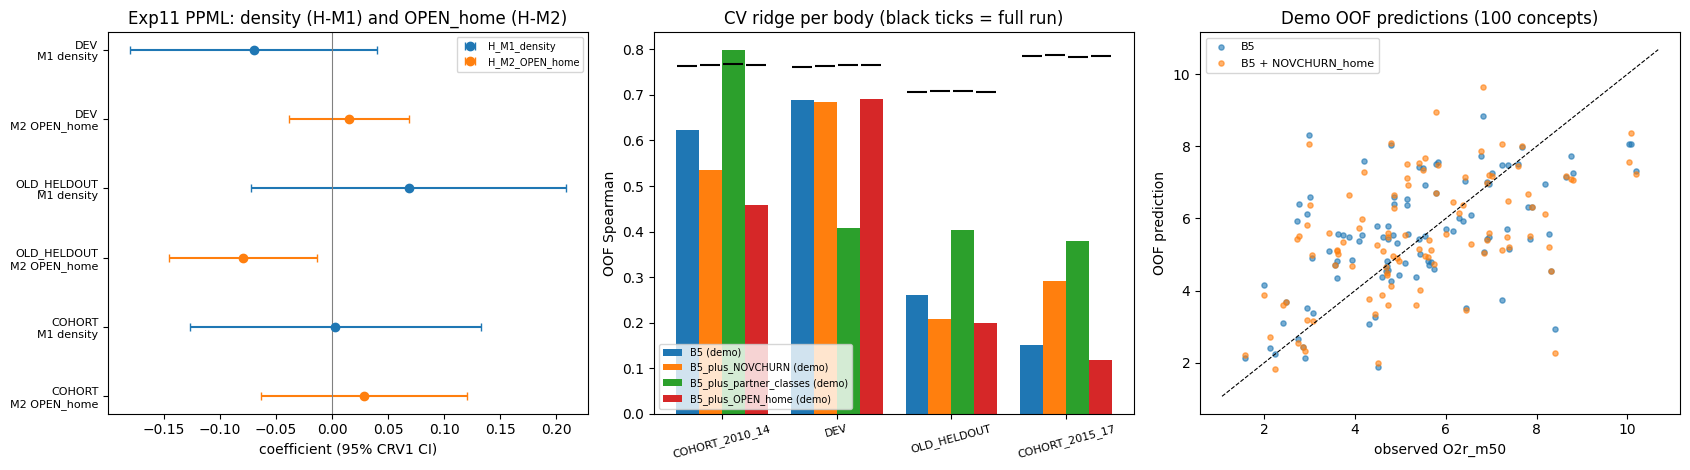

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))

# (1) Exp11 body-model coefficients with CRV1 CIs
lab = [f"{r.body}\n{r.term.replace('H_M1_', 'M1 ').replace('H_M2_', 'M2 ')}" for r in BM.itertuples()]
yy = np.arange(len(BM))
for term, col in (("H_M1_density", "tab:blue"), ("H_M2_OPEN_home", "tab:orange")):
    s = (BM.term == term).to_numpy()
    ax[0].errorbar(BM.b[s], yy[s], xerr=[(BM.b - BM.ci_lo)[s], (BM.ci_hi - BM.b)[s]], fmt="o", color=col, capsize=3, label=term)
ax[0].legend(fontsize=7)
ax[0].axvline(0, color="grey", lw=0.8)
ax[0].set_yticks(yy); ax[0].set_yticklabels(lab, fontsize=8); ax[0].invert_yaxis()
ax[0].set_title("Exp11 PPML: density (H-M1) and OPEN_home (H-M2)"); ax[0].set_xlabel("coefficient (95% CRV1 CI)")

# (2) OOF Spearman per body and model: demo (bars) vs full run (markers)
bodies = list(mo["metadata"]["cv_metrics"].keys())
w = 0.2
for k, nm in enumerate(models):
    sub = CM[CM.model == nm].set_index("body").loc[bodies]
    x = np.arange(len(bodies)) + (k - 1.5) * w
    ax[1].bar(x, sub.spearman_demo, w, label=f"{nm} (demo)")
    ax[1].scatter(x, sub.spearman_full, marker="_", s=200, color="k", zorder=3)
ax[1].set_xticks(np.arange(len(bodies))); ax[1].set_xticklabels(bodies, rotation=15, fontsize=8)
ax[1].set_ylabel("OOF Spearman"); ax[1].set_title("CV ridge per body (black ticks = full run)")
ax[1].legend(fontsize=7, loc="lower left")

# (3) demo OOF predictions: B5 vs B5+NOVCHURN against observed outcome
ex = pd.DataFrame(mo["datasets"][0]["examples"])
yobs = ex.output.astype(float)
ax[2].scatter(yobs, ex.predict_B5.astype(float), s=14, alpha=0.6, label="B5")
ax[2].scatter(yobs, ex.predict_B5_plus_NOVCHURN.astype(float), s=14, alpha=0.6, label="B5 + NOVCHURN_home")
lim = [yobs.min() - 0.5, yobs.max() + 0.5]
ax[2].plot(lim, lim, "k--", lw=0.8)
ax[2].set_xlabel("observed O2r_m50"); ax[2].set_ylabel("OOF prediction"); ax[2].legend(fontsize=8)
ax[2].set_title(f"Demo OOF predictions ({len(ex)} concepts)")
plt.tight_layout(); plt.show()